In [135]:
print("Hello Prime Trade AI group")

Hello Prime Trade AI group


## Introduction

This project analyzes the relationship between Bitcoin market sentiment (Fear/Greed) and trader performance using real trading data from Hyperliquid.

The goal is to identify behavioral patterns, evaluate profitability under different market conditions, and derive insights that can inform smarter trading strategies.

## Objective

- Analyze how market sentiment affects trader profitability
- Identify behavioral patterns during Fear and Greed periods
- Evaluate risk-taking tendencies
- Derive insights to improve trading strategies

## Methodology

1. Data Cleaning and preprocessing
2. Converting timestamps and aligning datasets
3. Merging trader data with sentiment data
4. Performing exploratory data analysis (EDA)
5. Identifying patterns and extracting insights

## Importing libraries

In [85]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [86]:
# Better visuals
sns.set(style="whitegrid")

## Datasets exploration

In [87]:
df_sentiment= pd.read_csv("fear_greed_index.csv")

In [88]:
df_sentiment

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05
...,...,...,...,...
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01


In [89]:
df_sentiment.shape

(2644, 4)

In [90]:
df_histdata = pd.read_csv("historical_data.csv")
df_histdata

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0000,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,382.20,420.80,SELL,25-04-2025 15:35,7546.600000,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,2124.10,2338.63,SELL,25-04-2025 15:35,7164.400000,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,423.40,466.16,SELL,25-04-2025 15:35,5040.300000,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.1010,3599.80,3963.38,SELL,25-04-2025 15:35,4616.900000,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12


In [91]:
df_histdata.shape

(211224, 16)

In [92]:
df_histdata1 = pd.read_csv('historical_data.csv', sep=None, engine='python')

In [93]:
df_histdata1.shape

(211224, 16)

In [94]:
df_histdata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [95]:
df_sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [96]:
df_sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


*No Null values in sentiment dataset*

In [97]:
df_sentiment.duplicated().sum()

np.int64(0)

*No Duplicates are found in this sentiment dataset*

In [98]:
df_sentiment.shape

(2644, 4)

In [99]:
df_sentiment.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [100]:
df_histdata.columns

Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [101]:
df_sentiment.describe()

,timestamp,value
count,2.644000e+03,2644.000000
mean,1.631899e+09,46.981089
std,6.597967e+07,21.827680
min,1.517463e+09,5.000000
25%,1.574811e+09,28.000000
50%,1.631900e+09,46.000000
75%,1.688989e+09,66.000000
max,1.746164e+09,95.000000


In [105]:
df_sentiment['classification'].unique()

array(['Fear', 'Extreme Fear', 'Neutral', 'Greed', 'Extreme Greed'],
      dtype=object)

In [106]:
df_sentiment['classification'].nunique()

5

In [107]:
df_histdata.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [108]:
df_histdata['Coin'].unique()

array(['@107', 'AAVE', 'DYDX', 'AIXBT', 'GMX', 'EIGEN', 'HYPE', 'SOL',
       'SUI', 'DOGE', 'ETH', 'kPEPE', 'TRUMP', 'ONDO', 'ENA', 'LINK',
       'XRP', 'S', 'BNB', 'BERA', 'WIF', 'LAYER', 'MKR', 'KAITO', 'IP',
       'JUP', 'USUAL', 'ADA', 'BTC', 'PURR/USDC', 'ZRO', '@7', '@19',
       '@21', '@44', '@48', '@11', '@15', '@46', '@61', '@28', '@45',
       '@9', '@41', '@38', 'kSHIB', 'GRASS', 'TAO', 'AVAX', '@2', '@6',
       '@8', '@10', '@12', '@16', '@17', '@35', '@26', '@24', '@32',
       '@29', '@31', '@33', '@34', '@36', '@37', '@47', '@53', '@74',
       'RUNE', 'CANTO', 'NTRN', 'BLUR', 'ZETA', 'MINA', 'MANTA', 'RNDR',
       'WLD', 'kBONK', 'ALT', 'INJ', 'STG', 'ZEN', 'MAVIA', 'PIXEL',
       'ILV', 'FET', 'STRK', 'CAKE', 'STX', 'ACE', 'PENDLE', 'AR', 'XAI',
       'APE', 'MEME', 'NEAR', 'SEI', 'FTM', 'MYRO', 'BIGTIME', 'IMX',
       'BADGER', 'POLYX', 'OP', 'TNSR', 'MAV', 'TIA', 'MERL', 'TON',
       'PURR', 'ME', 'CRV', 'BRETT', 'CHILLGUY', 'MOODENG', 'VIRTUAL',
       'CO

In [109]:
df_histdata['Coin'].nunique()

246

In [110]:
df_histdata['Side'].unique()

array(['BUY', 'SELL'], dtype=object)

### Data Cleaning

#### Cleaning sentiment dataset

In [111]:
# Convert date column to datetime
df_sentiment['date'] = pd.to_datetime(df_sentiment['date'])

# Keep only needed columns
df_sentiment = df_sentiment[['date', 'classification', 'value']]


# Rename for clarity
df_sentiment.rename(columns={'classification': 'sentiment'}, inplace=True)

df_sentiment.head()

/tmp/ipykernel_2884/3266632752.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sentiment.rename(columns={'classification': 'sentiment'}, inplace=True)


,date,sentiment,value
0,2018-02-01,Fear,30
1,2018-02-02,Extreme Fear,15
2,2018-02-03,Fear,40
3,2018-02-04,Extreme Fear,24
4,2018-02-05,Extreme Fear,11


#### Cleaning historical dataset

In [112]:
# Convert timestamp to datetime
df_histdata['Timestamp IST'] = pd.to_datetime(df_histdata['Timestamp IST'], errors='coerce')

# Create date column for merging
df_histdata['date'] = df_histdata['Timestamp IST'].dt.date
df_histdata['date'] = pd.to_datetime(df_histdata['date'])

df_histdata.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12


In [113]:
df_histdata.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,131999
Start Position,0
Direction,0
Closed PnL,0


In [114]:
df_sentiment.isnull().sum()

,0
date,0
sentiment,0
value,0


In [132]:
# Convert timestamp
df_histdata['Timestamp IST'] = pd.to_datetime(df_histdata['Timestamp IST'], errors='coerce')

# CREATE DATE COLUMN (MISSING STEP ❗)
df_histdata['date'] = df_histdata['Timestamp IST'].dt.date
df_histdata['date'] = pd.to_datetime(df_histdata['date'])

In [133]:
# df_histdata['date'] = df_histdata['Timestamp IST'].dt.date
# df_histdata['date']

In [134]:
# Debug step
print(df_histdata['date'].min(), df_histdata['date'].max())
print(df_sentiment['date'].min(), df_sentiment['date'].max())

print(len(set(df_histdata['date']).intersection(set(df_sentiment['date']))))

2023-01-05 00:00:00 2025-12-04 00:00:00
2018-02-01 00:00:00 2025-05-02 00:00:00
158


## Data Considerations

- Timestamp columns required proper conversion to ensure correct date alignment.
- Missing values in key columns such as PnL were handled to avoid incorrect analysis.
- Data merging was performed using date as the common key between datasets.

### Merge datasets

In [116]:
# Merge on date
merged = pd.merge(df_histdata,df_sentiment, on='date', how='inner')

merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,date,sentiment,value
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-02-12 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-02-12,Greed,70
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-02-12 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-02-12,Greed,70
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-02-12 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-02-12,Greed,70
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-02-12 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-02-12,Greed,70
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-02-12 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-02-12,Greed,70


In [117]:
merged.shape

(35864, 19)

In [118]:
merged.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,0


In [119]:
merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35864 entries, 0 to 35863
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Account           35864 non-null  object        
 1   Coin              35864 non-null  object        
 2   Execution Price   35864 non-null  float64       
 3   Size Tokens       35864 non-null  float64       
 4   Size USD          35864 non-null  float64       
 5   Side              35864 non-null  object        
 6   Timestamp IST     35864 non-null  datetime64[ns]
 7   Start Position    35864 non-null  float64       
 8   Direction         35864 non-null  object        
 9   Closed PnL        35864 non-null  float64       
 10  Transaction Hash  35864 non-null  object        
 11  Order ID          35864 non-null  int64         
 12  Crossed           35864 non-null  bool          
 13  Fee               35864 non-null  float64       
 14  Trade ID          3586

In [120]:
# # Instead of inner join
# # This keeps all trades and adds sentiment where available
# merged1 = pd.merge(df_histdata, df_sentiment, on='date', how='left')
# merged1

### Feature Engineering

In [121]:
# Profit or Loss category
merged['PnL_Type'] = merged['Closed PnL'].apply(lambda x: 'Profit' if x > 0 else 'Loss')

# Absolute trade size
merged['Trade_Size'] = merged['Size USD']

# Optional: Net profit after fees
merged['Net_PnL'] = merged['Closed PnL'] - merged['Fee']

### Exploratory Data Analysis (EDA)

#### 1.Profit vs Sentiment

sentiment
Extreme Fear       1.891632
Extreme Greed    205.816345
Fear             128.287950
Greed             53.988003
Neutral           27.088803
Name: Closed PnL, dtype: float64


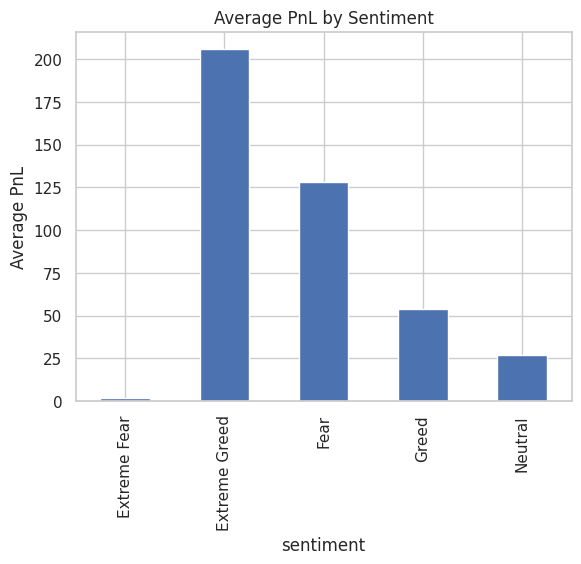

In [122]:
pnl_by_sentiment = merged.groupby('sentiment')['Closed PnL'].mean()

print(pnl_by_sentiment)

pnl_by_sentiment.plot(kind='bar', title="Average PnL by Sentiment")
plt.ylabel("Average PnL")
plt.show()

**Observation:**
Here greed >fear --> traders profit in bullish markets

The average PnL is higher during Greed periods, indicating that traders benefit from bullish market conditions.
In contrast, Fear periods show relatively lower profitability, reflecting uncertainty and risk-averse behavior.

In [136]:
# Median PnL
median_pnl = merged.groupby('sentiment')['Closed PnL'].median()
print(median_pnl)

sentiment
Extreme Fear     0.00000
Extreme Greed    0.96048
Fear             0.00000
Greed            0.00000
Neutral          0.00000
Name: Closed PnL, dtype: float64


**Observation:**
Median PnL confirms the trend observed in average PnL, reinforcing that Greed periods tend to be more profitable.
This reduces the impact of outliers and provides a more robust measure of trader performance.

#### 2.Number of Trades in Fear vs Greed

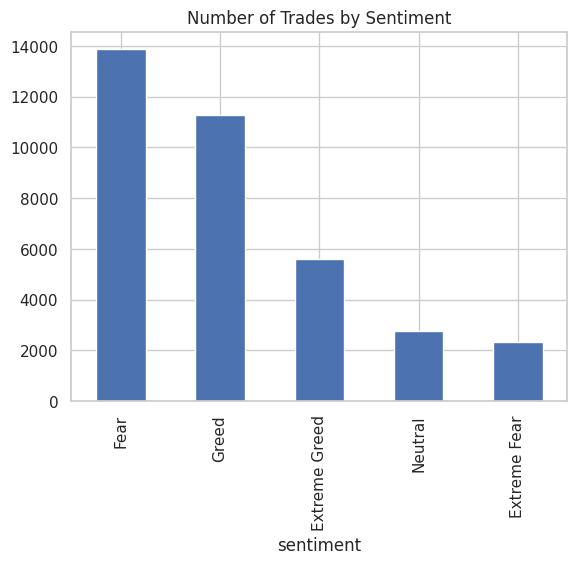

In [123]:
trade_count = merged['sentiment'].value_counts()

trade_count.plot(kind='bar', title="Number of Trades by Sentiment")
plt.show()

**Observation:**
More trades in Fear → panic trading

A higher number of trades occur during Fear periods, suggesting panic-driven or reactive trading behavior.
This indicates that traders tend to overtrade during uncertain market conditions.

#### 3.Profit vs Loss Distribution

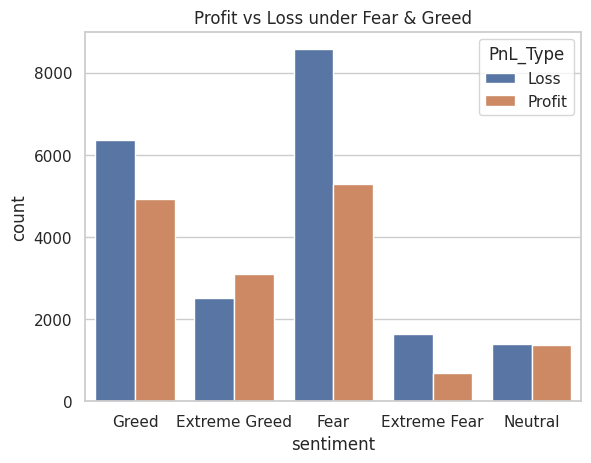

In [124]:
sns.countplot(data=merged, x='sentiment', hue='PnL_Type')
plt.title("Profit vs Loss under Fear & Greed")
plt.show()

**Observation:**
Fear periods exhibit a higher proportion of loss-making trades compared to Greed periods.
This highlights the negative impact of emotional decision-making during market downturns.

In [137]:
#Win rate
win_rate = (merged['Closed PnL'] > 0).mean() * 100
print(f"Overall Win Rate: {win_rate:.2f}%")

Overall Win Rate: 42.86%


**Observation:**
The overall win rate provides a clearer understanding of trading success across all conditions.
A moderate win rate suggests that consistent profitability requires strategic decision-making rather than frequent trading.

#### 4.Trade Size Behavior

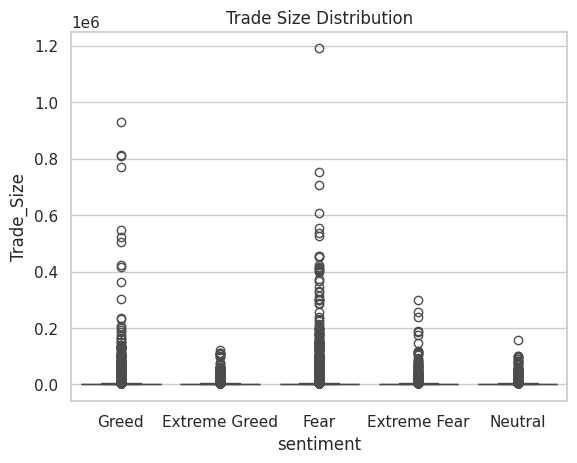

In [125]:
sns.boxplot(data=merged, x='sentiment', y='Trade_Size')
plt.title("Trade Size Distribution")
plt.show()

**Observation:**
Trade sizes are generally larger during Greed periods, reflecting increased confidence and risk appetite among traders.
However, larger trades may also expose traders to higher potential losses during volatile conditions.

#### 5.Buy vs Sell Behavior

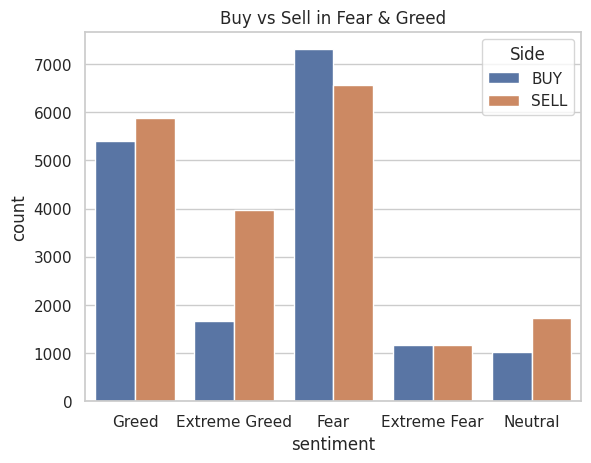

In [126]:
sns.countplot(data=merged, x='sentiment', hue='Side')
plt.title("Buy vs Sell in Fear & Greed")
plt.show()

**Observation:**
Buy trades are more frequent during Greed periods, while sell trades increase during Fear periods.
This indicates herd behavior, where traders follow market sentiment rather than independent strategies.

### ADVANCED ANALYSIS

#### Top Traders Analysis

In [127]:
top_traders = merged.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)

print(top_traders)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    1.478495e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    9.655887e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    2.056523e+05
0xbaaaf6571ab7d571043ff1e313a9609a10637864    2.013539e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    1.972949e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    1.425837e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    6.054430e+04
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    5.853488e+04
0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3    4.509997e+04
0x2c229d22b100a7beb69122eed721cee9b24011dd    4.304078e+04
Name: Closed PnL, dtype: float64


**Observation:**
Top traders consistently generate higher profits, indicating disciplined and strategy-driven trading behavior.
This suggests that successful trading is less influenced by market sentiment and more by individual decision-making.

#### Do Profitable Traders Behave Differently?

In [128]:
profitable = merged[merged['Closed PnL'] > 0]
loss_makers = merged[merged['Closed PnL'] <= 0]

print("Avg trade size (profit traders):", profitable['Trade_Size'].mean())
print("Avg trade size (loss traders):", loss_makers['Trade_Size'].mean())

Avg trade size (profit traders): 4666.353711776187
Avg trade size (loss traders): 5110.856922513907


#### Correlation Analysis

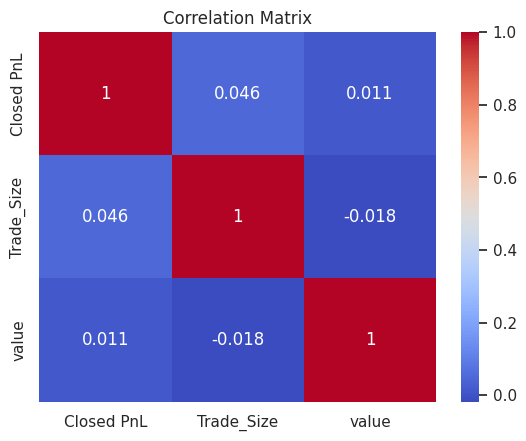

In [129]:
correlation = merged[['Closed PnL', 'Trade_Size', 'value']].corr()

sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

**Observation:**
The correlation between trade size, sentiment value, and PnL is relatively weak, suggesting that profitability is not solely dependent on trade size or sentiment.
This implies that trading strategy and timing play a more significant role in determining outcomes.

## Insights

**1. Market Sentiment vs Profitability**

The analysis shows a clear relationship between market sentiment and trader profitability.
During Greed periods, traders tend to generate higher average profits, indicating that bullish market conditions support profitable trading.
In contrast, Fear periods are associated with lower average PnL and higher losses due to increased uncertainty and volatility.

**2. Trading Activity Behavior**

The number of trades is significantly higher during Fear periods, suggesting that traders engage in panic-driven or reactive trading.
This indicates that emotional responses dominate decision-making during bearish market conditions.

**3. Profit vs Loss Distribution**

A higher proportion of trades result in losses during Fear periods, while Greed periods show a relatively better profit-to-loss ratio.
This highlights the impact of market sentiment on trading outcomes.

**4. Risk-Taking Patterns**

Traders tend to take larger positions during Greed periods, reflecting increased confidence and risk appetite.
However, this behavior can also expose traders to higher risks during sudden market reversals.

**5. Buy vs Sell Behavior**

The analysis reveals that traders are more likely to buy during Greed periods and sell during Fear periods, demonstrating herd behavior.
This suggests that many traders follow market sentiment rather than adopting independent strategies.

**Trader Performance Insights (Advanced)**

Top-performing traders exhibit more consistent profitability across different market conditions, indicating disciplined and strategy-driven trading behavior.
In contrast, less profitable traders are more influenced by market sentiment and tend to incur losses during volatile periods.

**Correlation Insight**

The correlation analysis indicates that trade size and sentiment have a limited direct relationship with profitability, suggesting that successful trading depends more on strategy than on trade size alone.

## Business Implications

- Traders should avoid emotional decisions during Fear periods
- Risk management is crucial during Greed phases
- Contrarian strategies may provide better returns

## Conclusion


This analysis demonstrates that market sentiment plays a significant role in shaping trader behavior and performance.
Fear-driven markets lead to panic trading and increased losses, while Greed-driven markets encourage aggressive risk-taking and higher profits.
Traders who maintain disciplined and strategic approaches, especially during volatile conditions, tend to outperform emotionally driven participants.
These insights can be leveraged to design smarter trading strategies that account for market psychology.

## Recommendations

* Traders should avoid emotional decision-making during Fear periods and focus on data-driven strategies.
* Risk management should be prioritized during Greed periods to avoid overexposure.
* Contrarian strategies (buying during Fear and selling during Greed) may yield better long-term results.